### student performance analysis 


In [10]:
import pyodbc
import pandas as pd

conn = pyodbc.connect(
    "DRIVER={SQL Server};"
    "SERVER=AdityaELitebook;"
    "DATABASE=projectStudentperformanceDb;"
    "Trusted_Connection=yes;"
)

print("Connected to database successfully")


Connected to database successfully


In [11]:
query = """
SELECT 
    s.studentid,
    s.studentname,
    s.department,
    s.year,
    sub.subjectname,
    m.marks,
    m.attendance
FROM marks m
JOIN students s ON m.studentid = s.studentid
JOIN subjects sub ON m.subjectid = sub.subjectid
"""


In [12]:
df = pd.read_sql(query, conn)

C:\Users\adity\AppData\Local\Temp\ipykernel_1956\1168034203.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [13]:
print(df)

   studentid studentname department  year subjectname  marks  attendance
0          1       Rahul        CSE     2       Maths     85          90
1          1       Rahul        CSE     2        DBMS     78          85
2          2       Anita        CSE     2       Maths     92          95
3          2       Anita        CSE     2          OS     88          92
4          3        Aman        ECE     2        DBMS     65          70


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   studentid    5 non-null      int64 
 1   studentname  5 non-null      object
 2   department   5 non-null      object
 3   year         5 non-null      int64 
 4   subjectname  5 non-null      object
 5   marks        5 non-null      int64 
 6   attendance   5 non-null      int64 
dtypes: int64(4), object(3)
memory usage: 412.0+ bytes


In [15]:
df.describe()

,studentid,year,marks,attendance
count,5.00000,5.0,5.000000,5.000000
mean,1.80000,2.0,81.600000,86.400000
std,0.83666,0.0,10.597169,9.864076
min,1.00000,2.0,65.000000,70.000000
25%,1.00000,2.0,78.000000,85.000000
50%,2.00000,2.0,85.000000,90.000000
75%,2.00000,2.0,88.000000,92.000000
max,3.00000,2.0,92.000000,95.000000


In [16]:
# subject wise anallysis 
subject_analysis = df.groupby("subjectname").agg(
    avg_marks = ("marks" , "mean"),
    max_marks = ("marks" , "max"),
    min_marks  =("marks" , "min")


)

In [17]:
print(subject_analysis)

             avg_marks  max_marks  min_marks
subjectname                                 
DBMS              71.5         78         65
Maths             88.5         92         85
OS                88.0         88         88


In [21]:
subject_performance = df.groupby("studentname").agg(
    best_performance = ("marks" , "max"),
    avg_attendance = ("attendance", "mean" )
)
print(df)
print(subject_performance)

   studentid studentname department  year subjectname  marks  attendance
0          1       Rahul        CSE     2       Maths     85          90
1          1       Rahul        CSE     2        DBMS     78          85
2          2       Anita        CSE     2       Maths     92          95
3          2       Anita        CSE     2          OS     88          92
4          3        Aman        ECE     2        DBMS     65          70
             best_performance  avg_attendance
studentname                                  
Aman                       65            70.0
Anita                      92            93.5
Rahul                      85            87.5


In [22]:
# correlation 
correlation = df["marks"].corr(df["attendance"])
print(f"marks vs attendance in each subject: {correlation}")

marks vs attendance in each subject: 0.992047479709066


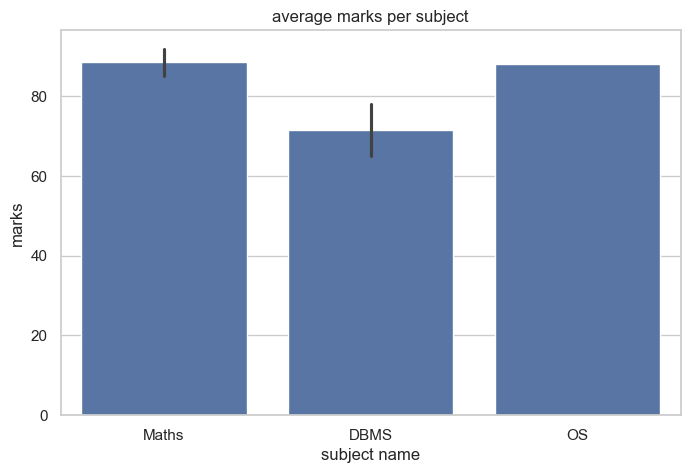

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style ="whitegrid")
plt.figure(figsize=(8,5))
sns.barplot(x = 'subjectname' , y = 'marks' , data = df)
plt.title("average marks per subject")
plt.xlabel("subject name")
plt.ylabel("marks")
plt.show()

<Axes: xlabel='attendance', ylabel='marks'>

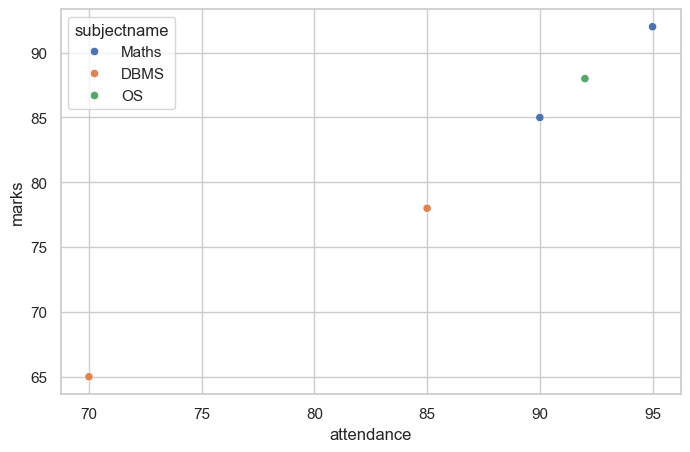

In [36]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x = "attendance",
    y = "marks",
    hue = "subjectname",
    data = df

)


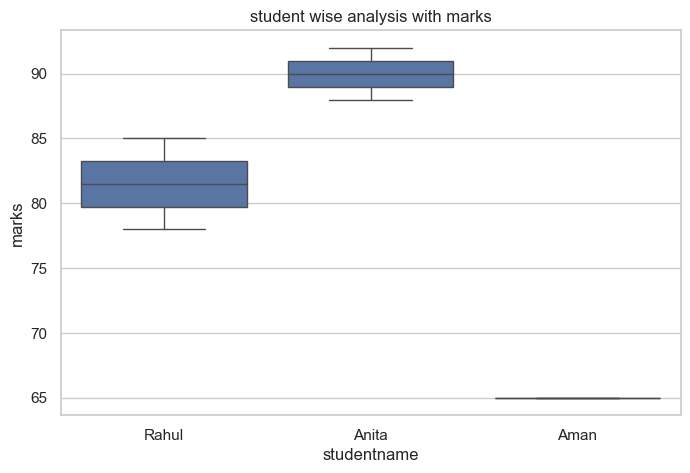

In [37]:
plt.figure(figsize = (8,5))
sns.boxplot(
    x = "studentname",
    y = "marks",
    data = df
)
plt.title("student wise analysis with marks")
plt.show()